# Look at RACMO climate for the ERA5 reanalysis data

1. How stable is the climate for two spinup periods?
2. What is the average change in precipitation, surface temperature, and snowmelt over the whole period?

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from scipy import stats


In [3]:
#set paths
variables     = ["ff10m","precip_liq","evap","sndiv","snowfall","snowmelt","tskin"]
file_variables = ["ff10m","precip","evap","sndiv","snowfall","snowmelt","tskin"]
RACMO_ts_dir = "/home/nld4814/scratch/FGRN055_era055/input/timeseries"
RACMO_avg_dir = "/home/nld4814/scratch/FGRN055_era055/input/averages"
MONTHLY_DIR = "/home/nld4814/scratch/FGRN055_era055/input/monthly"
MASK_FILE   = "/home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/FGRN055_Masks.nc"


In [4]:

# Check that monthly files exist
missing = [v for v in file_variables
           if not os.path.exists(f"{MONTHLY_DIR}/{v}_FGRN055_era055_1939-2023_monthly.nc")]
if missing:
    raise FileNotFoundError(
        f"Monthly files not found for: {missing}\n"
        f"Run:  sbatch 'RACMO climate/submit_racmo_monthly.sh'  to create them."
    )

# Load ice mask
ds_mask    = xr.open_dataset(MASK_FILE)
icemask_np = ds_mask["Icemask_GR"].squeeze(drop=True).values.astype(bool)
icemask_da = xr.DataArray(icemask_np, dims=["rlat", "rlon"])
ds_mask.close()

def load_spatial_mean(var):
    f  = f"{MONTHLY_DIR}/{var}_FGRN055_era055_1939-2023_monthly.nc"
    ds = xr.open_dataset(f)
    masked = ds[var].where(icemask_da)
    result = masked.mean(dim=["rlat", "rlon"]).load()
    ds.close()
    return result

# Load and spatial-average one variable at a time
data = {}
for var in file_variables:
    data[var] = load_spatial_mean(var)
    print(f"  {var}: {data[var].sizes}")

# Derive liquid precipitation from gridded files before discarding grids
f_precip   = f"{MONTHLY_DIR}/precip_FGRN055_era055_1939-2023_monthly.nc"
f_snowfall = f"{MONTHLY_DIR}/snowfall_FGRN055_era055_1939-2023_monthly.nc"
ds_p = xr.open_dataset(f_precip)
ds_s = xr.open_dataset(f_snowfall)
precip_liq_grid = (ds_p["precip"] - ds_s["snowfall"]).clip(min=0)
data["precip_liq"] = precip_liq_grid.where(icemask_da).mean(dim=["rlat", "rlon"]).load()
ds_p.close()
ds_s.close()
print(f"  precip_liq: {data['precip_liq'].sizes}")

print("All variables loaded.")


Ice-sheet cells: 58265
  ff10m: Frozen({'time': 1012})
  precip: Frozen({'time': 1012})
  evap: Frozen({'time': 1012})
  sndiv: Frozen({'time': 1012})
  snowfall: Frozen({'time': 1012})
  snowmelt: Frozen({'time': 1012})
  tskin: Frozen({'time': 1012})
  precip_liq: Frozen({'time': 1012})
All variables loaded.


In [ ]:
# define plotting function 


def plot_racmo_climate(data, start_date, end_date, suptitle):

    var_meta = {
        "ff10m":      ("Wind speed at 10 m",      "m s⁻¹"),
        "precip_liq": ("Liquid precipitation",     "kg m⁻² a⁻¹"),
        "evap":       ("Evaporation",              "kg m⁻² a⁻¹"),
        "sndiv":      ("Snow drifting",            "kg m⁻² a⁻¹"),
        "snowfall":   ("Snowfall",                 "kg m⁻² a⁻¹"),
        "snowmelt":   ("Snowmelt",                 "kg m⁻² a⁻¹"),
        "tskin":      ("Skin temperature",         "K"),
    }

    spy = 365.25*24*3600
    ncols = 4
    nrows = (len(variables) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True)

    sliced_data = {var: da.sel(time=slice(start_date, end_date)) for var, da in data.items()}

    for i, var in enumerate(variables):
        ax = axes.flat[i]
        t_yr = sliced_data[var].time.dt.year.values + (sliced_data[var].time.dt.month.values - 1) / 12

        if var in ("tskin", "ff10m"):
            vals      = sliced_data[var].values
            annual    = sliced_data[var].resample(time="YE").mean()
            annual_std = sliced_data[var].resample(time="YE").std()
            full_vals = data[var].values
        else:
            vals      = sliced_data[var].values * spy
            annual    = sliced_data[var].resample(time="YE").mean() * spy
            annual_std = sliced_data[var].resample(time="YE").std() * spy
            full_vals = data[var].values * spy

        ax.plot(t_yr, vals, lw=0.8, color="steelblue", alpha=0.7)

        # Annual mean ± 1 std
        t_ann = annual.time.dt.year.values + 0.5
        ann_vals = annual.values
        ann_std  = annual_std.values
        ax.plot(t_ann, ann_vals, lw=2, color="navy", label="annual mean ± 1σ")
        ax.fill_between(t_ann, ann_vals - ann_std, ann_vals + ann_std,
                        color="navy", alpha=0.15)

        # Linear trend with 95% confidence interval
        result = stats.linregress(t_yr, vals.astype(float))
        slope, intercept, stderr = result.slope, result.intercept, result.stderr
        fit_line = slope * t_yr + intercept

        n = len(t_yr)
        t_crit = stats.t.ppf(0.975, df=n - 2)
        t_mean = t_yr.mean()
        se_line = stderr * np.sqrt(1/n + (t_yr - t_mean)**2 / np.sum((t_yr - t_mean)**2))
        ci = t_crit * se_line

        total_change = fit_line[-1] - fit_line[0]
        total_uncert = stderr * t_crit * (t_yr[-1] - t_yr[0])
        ax.plot(t_yr, fit_line, "r--", lw=1.2,
                label=f"trend: {slope * 10:.3g} ± {stderr * t_crit * 10:.2g} / decade\n"
                      f"total: {total_change:+.3g} ± {total_uncert:.2g}")
        ax.fill_between(t_yr, fit_line - ci, fit_line + ci, color="red", alpha=0.15)

        # Fix y-axis to full-timeseries range
        ax.set_ylim(np.nanmin(full_vals), np.nanmax(full_vals))

        label, unit = var_meta[var]
        ax.set_title(label, fontsize=11)
        ax.set_ylabel(unit, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for j in range(len(variables), len(axes.flat)):
        axes.flat[j].set_visible(False)

    # Label x-axis on each visible bottom-row panel
    for i in range((nrows - 1) * ncols, len(variables)):
        axes.flat[i].set_xlabel("Year", fontsize=10)

    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()


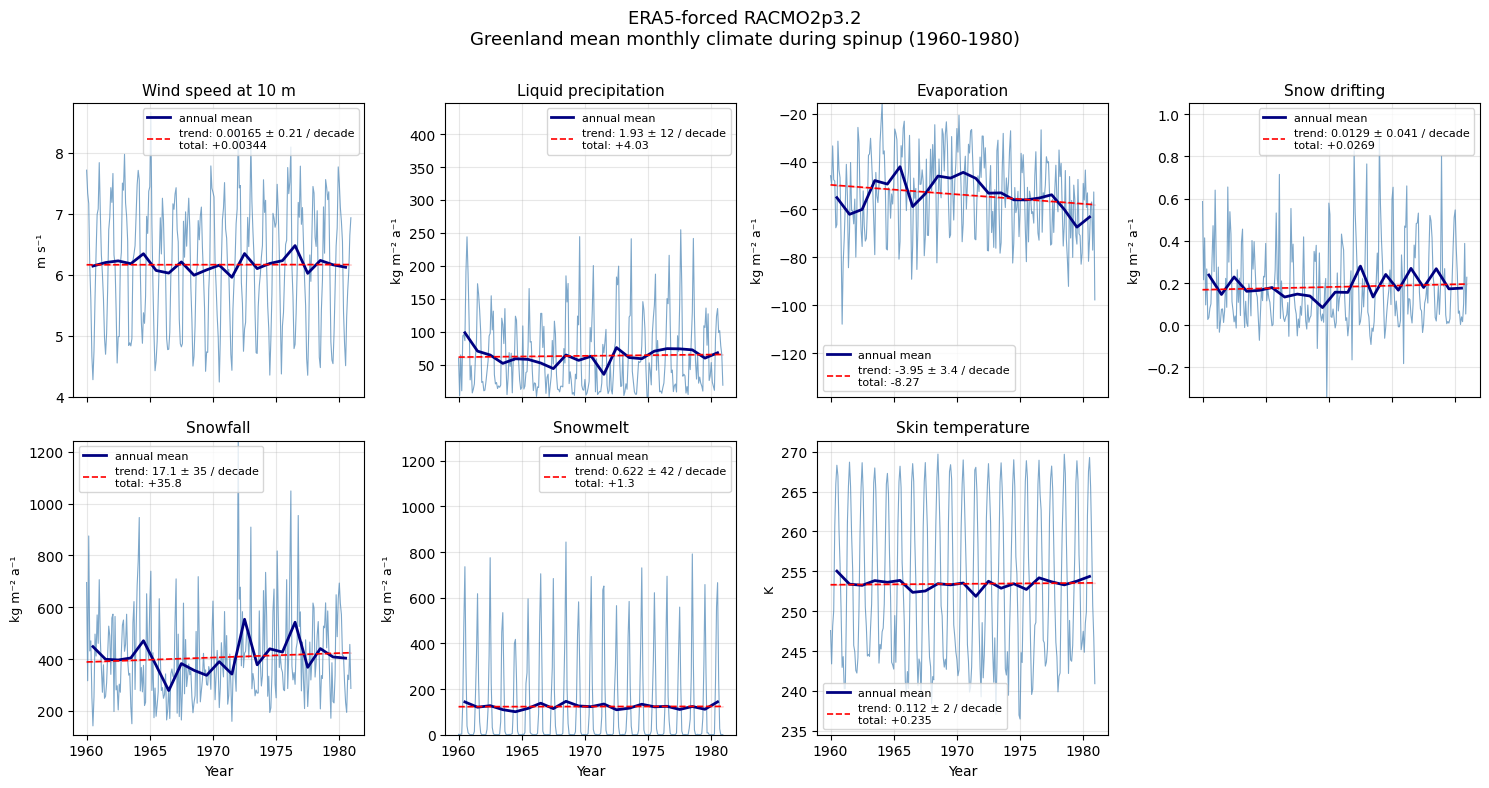

In [6]:
start_date = "1960"
end_date = "1980"
plot_racmo_climate(data, start_date, end_date, suptitle = f"ERA5-forced RACMO2p3.2\nGreenland mean monthly climate during spinup ({pd.to_datetime(start_date).year}-{pd.to_datetime(end_date).year})\n")

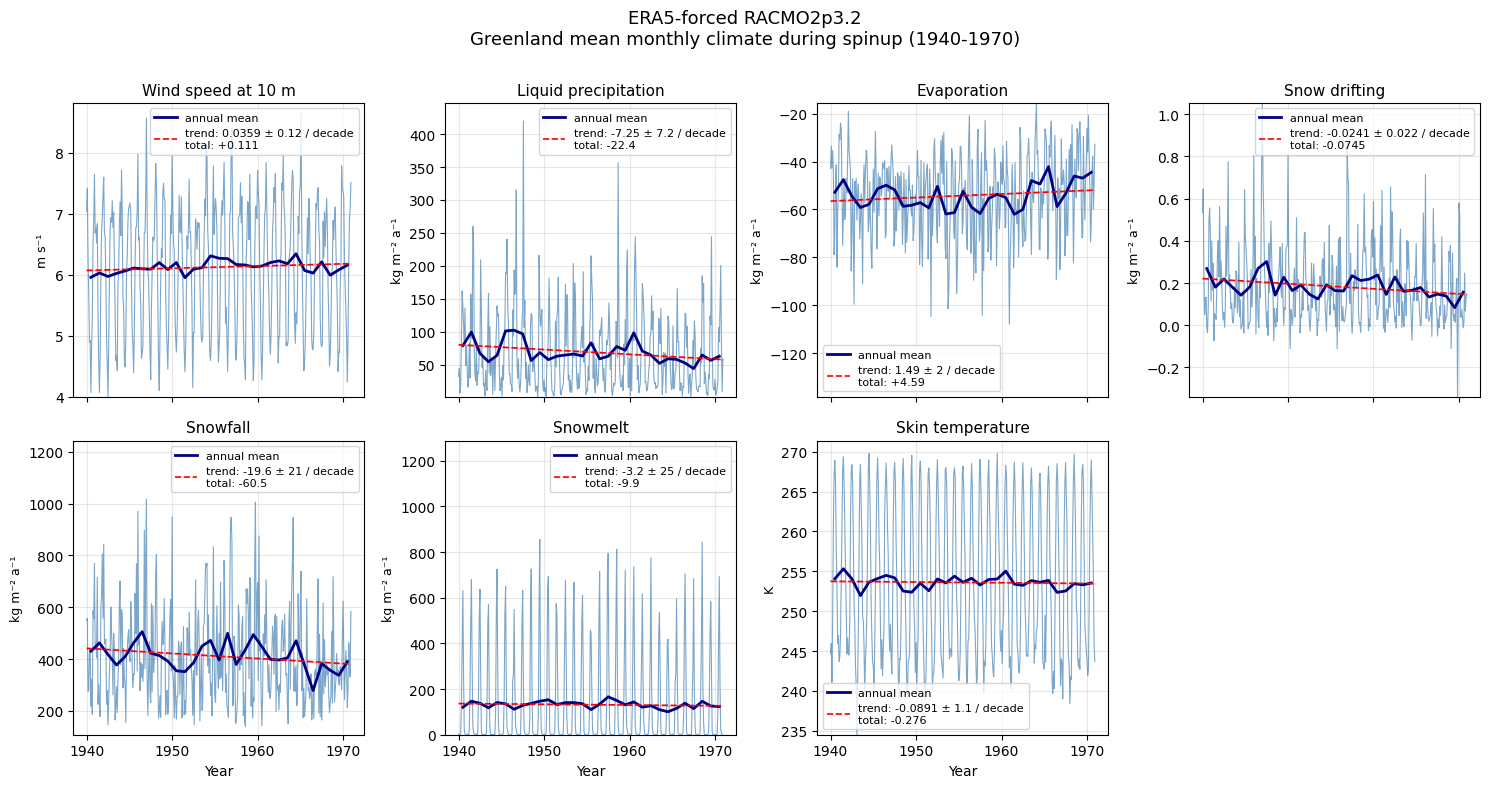

In [7]:
start_date = "1940"
end_date = "1970"
plot_racmo_climate(data, start_date, end_date, suptitle = f"ERA5-forced RACMO2p3.2\nGreenland mean monthly climate during spinup ({pd.to_datetime(start_date).year}-{pd.to_datetime(end_date).year})\n")

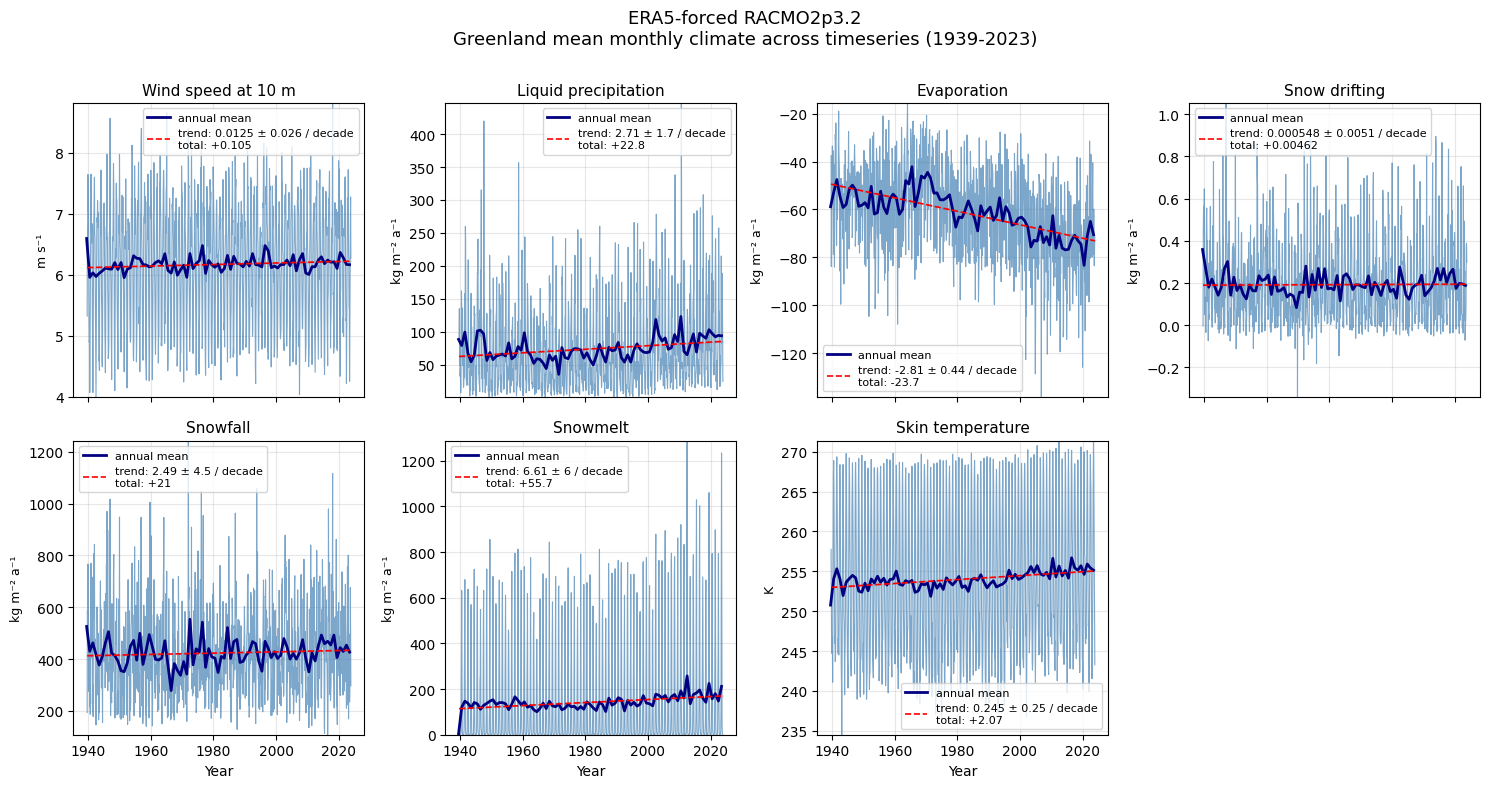

In [8]:
start_date = "1939"
end_date = "2023"
plot_racmo_climate(data, start_date, end_date, suptitle = f"ERA5-forced RACMO2p3.2\nGreenland mean monthly climate across timeseries ({pd.to_datetime(start_date).year}-{pd.to_datetime(end_date).year})\n")


In [ ]:
spy = 365.25*24*3600
var = "tskin"
sliced_data = {var: da for var, da in data.items()}
annual    = sliced_data[var].resample(time="YE").mean() * spy
annual[1] - annual[-1]

<xarray.DataArray 'tskin' ()> Size: 4B
array(-3.40608e+07, dtype=float32)

In [10]:
annual

<xarray.DataArray 'tskin' (time: 85)> Size: 340B
array([7.9133850e+09, 8.0174971e+09, 8.0569830e+09, 8.0168940e+09,
       7.9510513e+09, 8.0040878e+09, 8.0183025e+09, 8.0308772e+09,
       8.0213740e+09, 7.9688468e+09, 7.9643796e+09, 8.0000753e+09,
       7.9701125e+09, 8.0167337e+09, 8.0010317e+09, 8.0276782e+09,
       8.0036091e+09, 8.0194222e+09, 7.9928172e+09, 8.0145935e+09,
       8.0166400e+09, 8.0477983e+09, 7.9963361e+09, 7.9915361e+09,
       8.0102308e+09, 8.0036270e+09, 8.0110070e+09, 7.9638011e+09,
       7.9692165e+09, 7.9981466e+09, 7.9934894e+09, 8.0007188e+09,
       7.9479716e+09, 8.0078090e+09, 7.9802107e+09, 7.9979756e+09,
       7.9753231e+09, 8.0212649e+09, 8.0054354e+09, 7.9933471e+09,
       8.0081567e+09, 8.0267520e+09, 7.9832202e+09, 7.9899940e+09,
       7.9674527e+09, 8.0139310e+09, 8.0194304e+09, 8.0115277e+09,
       8.0336604e+09, 8.0045757e+09, 7.9818056e+09, 7.9979894e+09,
       8.0094587e+09, 7.9849728e+09, 7.9915100e+09, 7.9966546e+09,
       8.0085519e+09, 8.0515318e+09, 8.0181309e+09, 8.0350858e+09,
       8.0149658e+09, 8.0208963e+09, 8.0318505e+09, 8.0409784e+09,
       8.0659748e+09, 8.0419333e+09, 8.0695173e+09, 8.0374461e+09,
       8.0309110e+09, 8.0427535e+09, 8.0172836e+09, 8.0983951e+09,
       8.0246292e+09, 8.0675927e+09, 8.0288128e+09, 8.0506132e+09,
       8.0200607e+09, 8.1005993e+09, 8.0601001e+09, 8.0516106e+09,
       8.0690596e+09, 8.0350239e+09, 8.0758723e+09, 8.0604416e+09,
       8.0515579e+09], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 680B 1939-12-31 1940-12-31 ... 2023-12-31